# FuseMap Tutorial II: Integrating Spatial Transcriptomics Data Across Different Technology Platforms

In this tutorial, we'll demonstrate how to use FuseMap to integrate spatial transcriptomics data from different technology platforms - specifically, combining image-based (STARmap) and sequencing-based (Slide-seq) technologies. This integration is particularly challenging and important because:

1. Different technologies capture spatial information at different resolutions
2. The data formats and characteristics vary significantly between platforms
3. The gene capture efficiency and coverage differ between methods

We'll walk through each step carefully, explaining the rationale and technical details along the way.

## 1. Data preparation

For this tutorial, we'll use mouse brain data from two different platforms:

- STARmap data: A high-resolution image-based spatial transcriptomics method (Shi et al., [Nature paper](https://www.nature.com/articles/s41586-023-06569-5#data-availability))
- Slide-seq data: A sequencing-based spatial transcriptomics method with high throughput (Langlieb et al., [Nature paper](https://www.nature.com/articles/s41586-023-06818-7#data-availability))

Both datasets are from mouse brain tissue, which allows us to demonstrate cross-platform integration while maintaining biological relevance.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import json
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from time import time

## 1. Download the example data

STARmap (image-based, annotated) and Stereo-seq (sequencing-based) mouse brain sections
(~1.3 GB total).

In [2]:
import gdown

os.makedirs("./tutorial2_data", exist_ok=True)
for fid, fname in [("1jPniIBchuYUPgBdyn16bjt11orsYiSKj", "starmap.h5ad"),
                   ("17SZwS2qyOV4xNss9xb4UXYnAyz20Wery", "stereoseq_mousebrain.h5ad")]:
    if not os.path.exists(f"./tutorial2_data/{fname}"):
        gdown.download(id=fid, output=f"./tutorial2_data/{fname}", quiet=False)

data_dir_list = ["./tutorial2_data/starmap.h5ad", "./tutorial2_data/stereoseq_mousebrain.h5ad"]

## 2. Integrate — one call

Cross-technology integration works exactly like same-technology integration: put both files
in one folder and call `fusemap.integrate`. Gene panels are consolidated automatically through
the universal gene embedding.

In [3]:
import fusemap

output_dir = "./output_tutorial2"
fusemap.integrate("./tutorial2_data", output_dir)

2026-09-05 03:05:42,043 - INFO - Arguments: {'output_save_dir': './output_tutorial2', 'keep_celltype': '', 'keep_tissueregion': '', 'use_llm_gene_embedding': 'false', 'pretrain_model_path': ''}


2026-09-05 03:05:46,395 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-05 03:06:44,945 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-05 03:06:45,630 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-05 03:06:46,400 - INFO - 

number of genes in each section:[1022, 23352], Number of all genes: 23395.



...

2026-09-05 03:06:56,529 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-05 03:06:56,546 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache ENABLED (43341 x 1022 = 0.165 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-05 03:06:56,710 - INFO - [FuseMap loader] atlas 1: dense CPU feature cache DISABLED (50140 x 23352 = 4.362 GB >= 2.0 GB limit); keeping scalable scipy CSR slicing.


2026-09-05 03:06:56,712 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-05 03:06:57,129 - INFO - 

---------------------------------- Finish ----------------------------------



## 4. Visualization

### read single-cell embedding

Text(0.5, 1.0, 'Single-cell embedding, colored by sample ID')

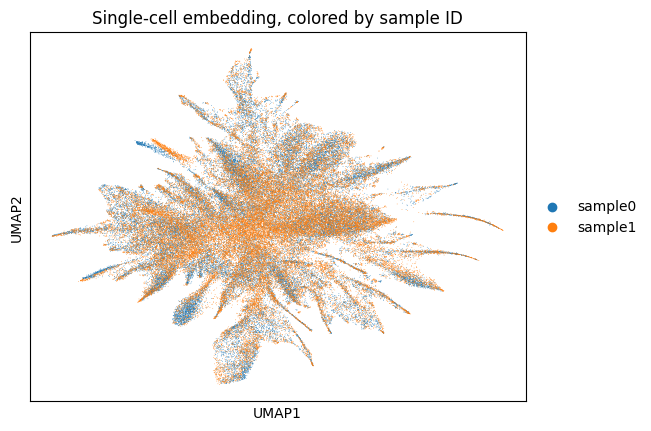

In [4]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='batch',size=1, show=False)
ax.set_title('Single-cell embedding, colored by sample ID')

### read spatial embedding

Text(0.5, 1.0, 'Single-cell embedding, colored by sample ID')

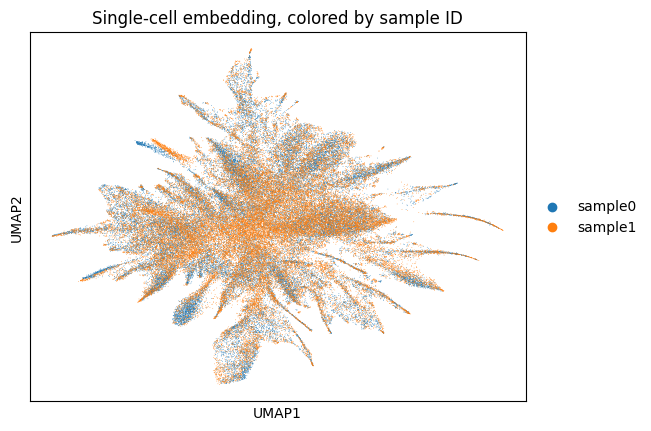

In [5]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='batch',size=1, show=False)
ax.set_title('Single-cell embedding, colored by sample ID')

### read gene embedding

Text(0.5, 1.0, 'Single-cell embedding, colored by sample ID')

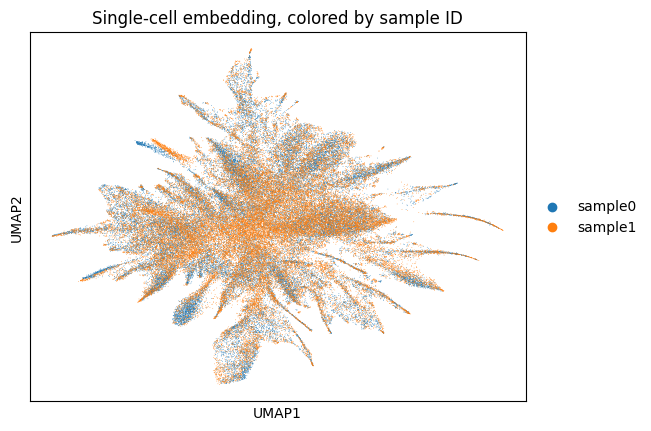

In [6]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='batch',size=1, show=False)
ax.set_title('Single-cell embedding, colored by sample ID')

## 5. Cell deconvolution in sequencing-based data

In [7]:
from fusemap.deconvolution import get_cell_spot_embedding, get_representative_embeddings, optimize_cell_spot_assignment, evaluate_topk_accuracy, cell_type_mapping_starmap_stereomap
import torch
device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
import numpy as np
import json
n_prototypes = 5
lambda_reg = 0.1

In [8]:
start_time = time()
ad_cell_embd = sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
ad_sc = sc.read_h5ad(data_dir_list[0])
ad_sp = sc.read_h5ad(data_dir_list[1])
ad_cell_embd.obs['cell_or_spot'] = 'unknown'
# Assign values conditionally based on the 'batch' column
ad_cell_embd.obs.loc[ad_cell_embd.obs['batch'] == 'sample0', 'cell_or_spot'] = 'cell'
ad_cell_embd.obs.loc[ad_cell_embd.obs['batch'] == 'sample1', 'cell_or_spot'] = 'spot'

# Extract embeddings and cell type information
cell_embd, spot_embd, cell_type = get_cell_spot_embedding(ad_cell_embd, cell_or_spot_column='cell_or_spot', cell_type_column='gtTaxonomyRank4')
cell_label = pd.Categorical(cell_type).codes # Cell types for merscope

# Obtain representative embeddings for each cell type
Z_representative = get_representative_embeddings(cell_embd, cell_label, n_prototypes=n_prototypes, method="kmeans")

# Convert numpy arrays to torch tensors
Z_prototypes = torch.tensor(Z_representative, dtype=torch.float32, device=device)
Z_spots = torch.tensor(spot_embd, dtype=torch.float32, device=device)

In [9]:
# Optimize the cell-spot assignment matrix
M_final = optimize_cell_spot_assignment(Z_prototypes, Z_spots, lr=0.02, num_epochs=1000, device=device)

# Save the final assignment matrix
suffix = f'{n_prototypes}_{lambda_reg}'
np.save(os.path.join(output_dir, f"cell_spot_assignment_{suffix}.npy"), M_final)

img_cate = pd.Categorical(ad_cell_embd.obs[ad_cell_embd.obs['batch'] == 'sample0']['gtTaxonomyRank4']).categories.tolist()

ground_truth = ad_sp.obs['gt_cell_type_main'].tolist()

res = {}
for k in [1, 2, 3, 4, 5]:
    res[k] = evaluate_topk_accuracy(M_final, cell_type_mapping_starmap_stereomap, img_cate, ground_truth, ad_sp.X.shape[0], k=k)
    
res['time'] = time() - start_time

with open(os.path.join(output_dir, f"deconv_accuracy_{suffix}.json"), 'w') as f:
    json.dump(res, f, indent=4)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 1/1000 [00:00<08:44,  1.90it/s]

  2%|▏         | 15/1000 [00:00<00:31, 31.16it/s]

Epoch 0, Total Loss: 0.6521, Reconstruction Loss: 0.3293, Regularization Loss: 0.0323


  3%|▎         | 29/1000 [00:00<00:17, 55.67it/s]

...

 78%|███████▊  | 39303/50140 [00:01<00:00, 26468.60it/s]

 84%|████████▍ | 42112/50140 [00:01<00:00, 26908.64it/s]

 92%|█████████▏| 45920/50140 [00:01<00:00, 27302.87it/s]

100%|██████████| 50140/50140 [00:01<00:00, 27672.14it/s]

Top-5 accuracy: 54.1%, 24543/45355


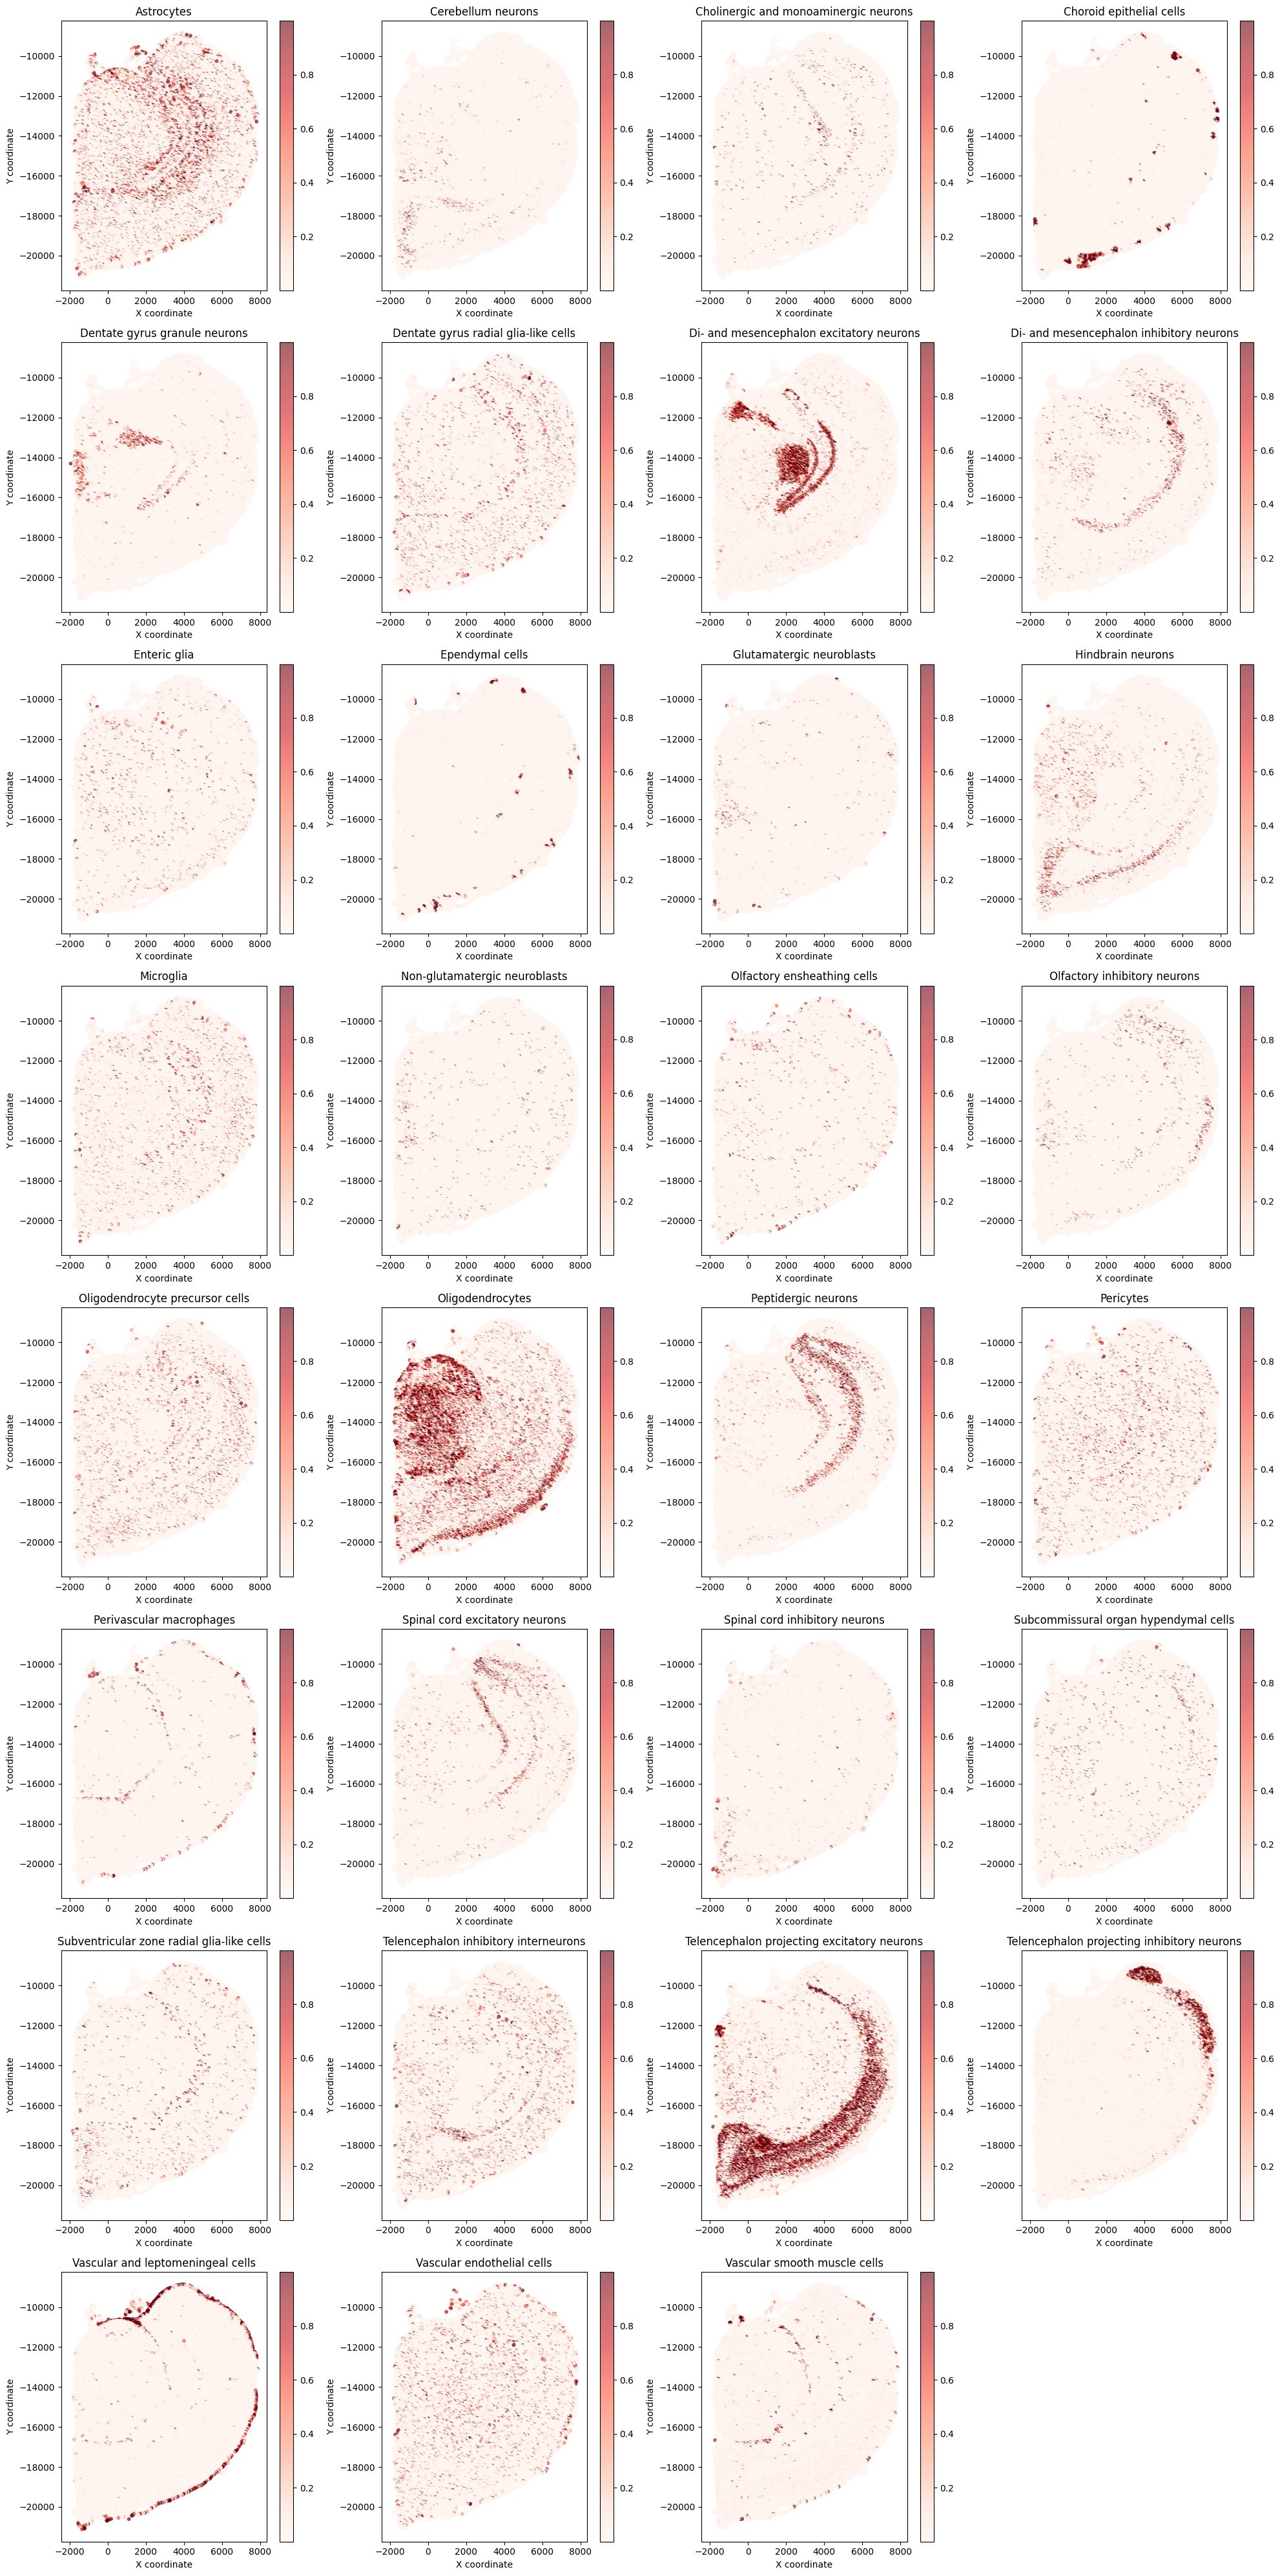

In [10]:
# plot each spot with color showing a cell type light/strong
# Create a figure with subplots for each cell type
img_cate = img_cate[:-1]  # remove 'nan'
n_cell_types = len(img_cate)
n_cols = 4  # You can adjust this
n_rows = (n_cell_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

# Get spatial coordinates from the Stereo-seq data
spatial_coords = np.array([ad_sp.obs['x'].astype(float), 
                          ad_sp.obs['y'].astype(float)]).T

# Plot each cell type separately
for idx, cell_type in enumerate(img_cate):
    ax = axes[idx]
    
    # Get the proportions for this cell type from M_final
    cell_type_proportions = M_final[idx, :]
    
    # Create scatter plot
    scatter = ax.scatter(spatial_coords[:, 0], 
                        spatial_coords[:, 1],
                        c=cell_type_proportions,
                        cmap='Reds',
                        alpha=0.6,
                        s=10)
    
    ax.set_title(f'{cell_type}')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    fig.colorbar(scatter, ax=ax)

# Remove empty subplots if any
for idx in range(len(img_cate), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
